# Week 5 - Bivariate Analysis

## Please run the cells of the notebook as you get to them while reading

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lesson: Bivariate graphs

In this lesson, we'll consider some bivariate plots: scatter plots, line plots, waterfall plots, area plots, and pair plots.  We'll also look at bivariate statistics such as correlations, ratios, and percentages.  First, let's create some data.

In [3]:
np.random.seed(0)
numpoints = 100
lesson_series_uniform = np.round(np.random.random(size = numpoints) * 100, 2)
lesson_series_base = np.round(np.random.random(size = numpoints)**2 * 100, 2)
lesson_series_skewed = lesson_series_base + np.random.normal(scale = 10, size = numpoints)
lesson_series_reverse = 100 - lesson_series_base + np.random.normal(scale = 10, size = numpoints)

This scatter plot puts one series against another.  The two series are anticorrelated - one goes up when the other goes down.

<Axes: >

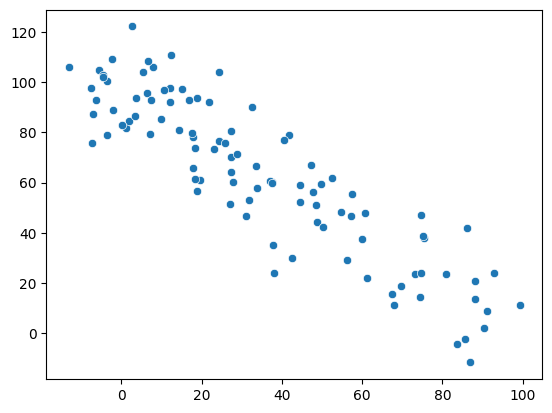

In [4]:
sns.scatterplot(x = lesson_series_skewed, y = lesson_series_reverse)

This pair plot compares three series against one another.  The diagonal shows the histogram of each series, while the non-diagonal entries plot two different series against each other.  The result in column 1, row 2 is a scatter plot that compares series #1 with series #2.  In effect, when the logic of the pair plot tells us to plot a series against itself (column 1, row 1), we draw a histogram.  (It would be silly to draw a scatter plot of a series against itself).  Because series #1 is not based on the "base" series, it is not correlated with series #2 or series #3, so the four scatter plots that compare series #1 to #2 and #3 look patternless.  The two scatter plots that compare series #2 with series #3 do appear to be correlated due to the "base" series that they share in common.

In [5]:
df = pd.DataFrame(np.array([lesson_series_uniform, lesson_series_skewed, lesson_series_reverse]).T, columns = ['uniform', 'skewed', 'reverse'])

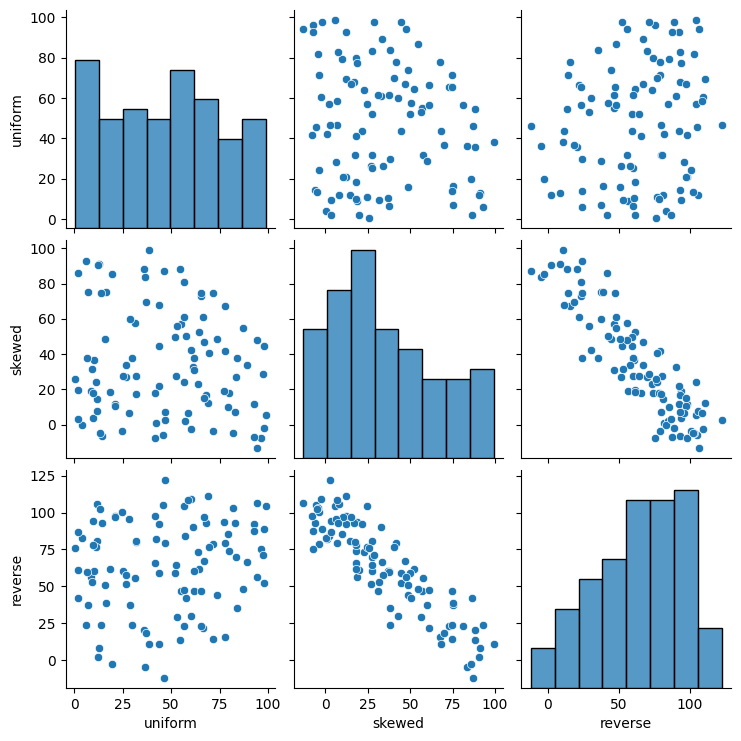

In [6]:
sns.pairplot(df)

We can compute the correlation coefficience between each pair.

In [7]:
print("Correlations:", df.corr())

Correlations:           uniform    skewed   reverse
uniform  1.000000 -0.145022  0.149771
skewed  -0.145022  1.000000 -0.894549
reverse  0.149771 -0.894549  1.000000


This shows that there is a strong negative correlation between the "skewed" and "reverse" datasets (a larger negative number in row 2, column 3 and in row 3, column 2) and almost no correlation between the "uniform" dataset and the others (the much smaller numbers at those locations in the table.)

Q: What is a correlation telling us?

If the correlation is large (close to 1) it tells us that the two variables are usually either both large or both small in value.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the lower left to upper right.

If the correlation is very negative (close to -1), it tells us that when one variable is large, the other is small.  If we graphed them on a scatter plot, the shape would be close to a straight line, positioned diagonally from the upper left to lower right.

If the correlation is zero, it tells us that the two variables, plotted on a scatter plot, would form a cloud.  The cloud can have different shape - for instance, it could be square or circular - but it cannot look like a diagonal line.  Knowing the value of one variable would tell you nothing about the value of the other variable.  (At least, it would not tell you whether the other variable is large or small).

The correlation coefficients above are called by the letter R.  R can be positive or negative, and lies between -1 and 1.  If we square R, we get a value called $R^2$ which is sometimes used to describe the correlation.  Unless R = 0 or 1, $R^2$ will be smaller in magnitude than R (and always positive), which means that it is very important to know if you are talking about R or $R^2$.  Since the values above can be negative, you can know for sure that they are R values, not $R^2$.

Q: How do you decide if a correlation is strong?

It depends on the application.  Some sources say that a correlation of R = 0.7 or 0.8 is strong, but in other applications (say, the social sciences) a correlation of 0.5 might be considered quite strong.  It is not unusual for social scientists to report correlations even as low a 0.2 as being important.

Q: What is the purpose of finding a correlation?

Here are a few:

1. Variables that are correlated with a target variable might be especially useful in predicting that variable.  This might also suggest that a linear model could work.  On the other hand, just because there are no pairwise correlations doesn't mean that a linear model won't work.  For example, if you select X, Y, and Z from this list of four possibilities: \[\[X = 1, Y = 0, Z = 0], \[X = 0, Y = 1, Z = 0], \[X = 0, Y = 0, Z = 1], \[X = 1, Y = 1, Z = 1]] then any two variables are completely uncorrelated, but the sum of the three is usually 1.  So the linear model Z = 1 - X - Y is accurate in three out of four cases even though all pairwise correlations are zero.

2. Variables that are very correlated with each other might be redundant.  In the extreme case, two variables that have a correlation of 1.0 are "linearly dependent" - they essentially provide the same information.  For example, if one column is a height in inches, and another is a height in centimeters, then they are redundant.  Moreover, if you use two highly correlated variables as predictors, the results will be somewhat unpredictable.  For example, if HI is the height in inches and HC is the height in centimeters, then the following formulas are all equivalent: HC, 2.54 * HI, 0.5 * HC + 1.27 * HI, 1001 * HC - 2540 * HI.  So there's no knowing which one you'll get if you try to build a model based on these variables.  The last one in particular is a little bit surprising, given the large coefficients, but it could very well be the result of a linear regression analysis.

3. Correlation can help you to detect problems with the data.  If two variables are correlated but shouldn't be, or if they're not correlated but should be, there might be something wrong with the data.  It's important to test the data to see if it makes sense.

4. Correlations can be interesting things to report.  If your client or organization is asking for a verbal explanation of the dataset, they might be interested in knowing about any correlations for reasons of their own.

A waterfall chart shows a value after a sequence of inputs and outputs.

In [8]:
import plotly.graph_objects as go

fig = go.Figure(go.Waterfall(
    name='This title is not displayed',
    orientation='v',
    measure=['absolute','relative','relative','relative','relative'],
    x=["2023-Jan", "receipts-in", "interest-in", "expenses-out", "interest-out", "2024-Jan"],
    textposition='outside',
    text=['Total','after-receipts','after-interest','after-expenses','after-interest'],
    y=[123.45,42.08,21.97,-54.31,-50.23],
    connector=dict(line=dict(color='rgb(63, 63, 63)'))
))

fig.update_layout(
    title='Waterfall Plot',
    showlegend=False
)
fig.update_yaxes(range=[-1,230])
fig.show()

A line plot is typically associated with a time or date range.  It shows how a variable rises and falls over a period of time.

<Axes: xlabel='None'>

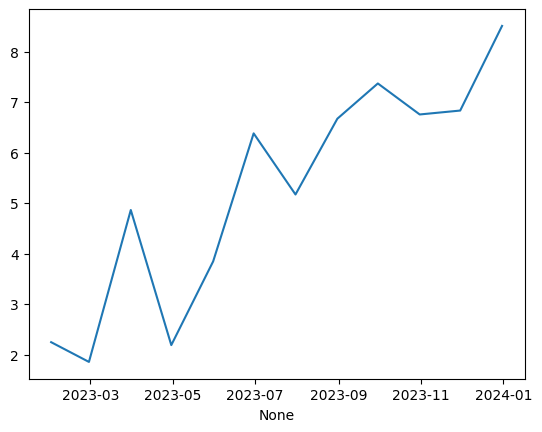

In [9]:
numdates = 12
time_series = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
sns.lineplot(x = datearray, y = time_series)

An area plot stacks one curve on top of another.  In the graph below, the top line shows the sum of the two series (ser1 + ser2) while the bottom line just shows ser1.

<Axes: >

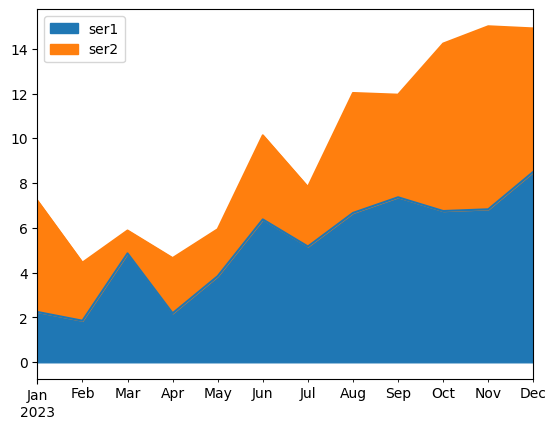

In [10]:
time_series_2 = np.random.random(size = numdates) * 5 + np.arange(numdates) / 3
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 2. Weekly graph question

Below is a pair plot showing the correlation between the levels of chemical A, B, and C in a water sample.  If you had to choose just _three_ of the nine graphs in the pair plot to display, which would you choose?  How would you alter the way these graphs are displayed to make them clearer or more informative?  Would you fit any of these graphs to a line or curve?  Why or why not?  What if you had to choose just _one_?  What if you had to choose _six_?

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)
num_data = 100
base_data = np.random.random(size = num_data)
chem1 = base_data + np.random.normal(size = num_data) * 0.1
chem2 = base_data**2 + np.random.normal(size = num_data) * 0.1
chem3 = 1 - base_data + np.random.normal(size = num_data) * 0.1
df_chem = pd.DataFrame({'chem1':chem1,'chem2':chem2,'chem3':chem3})

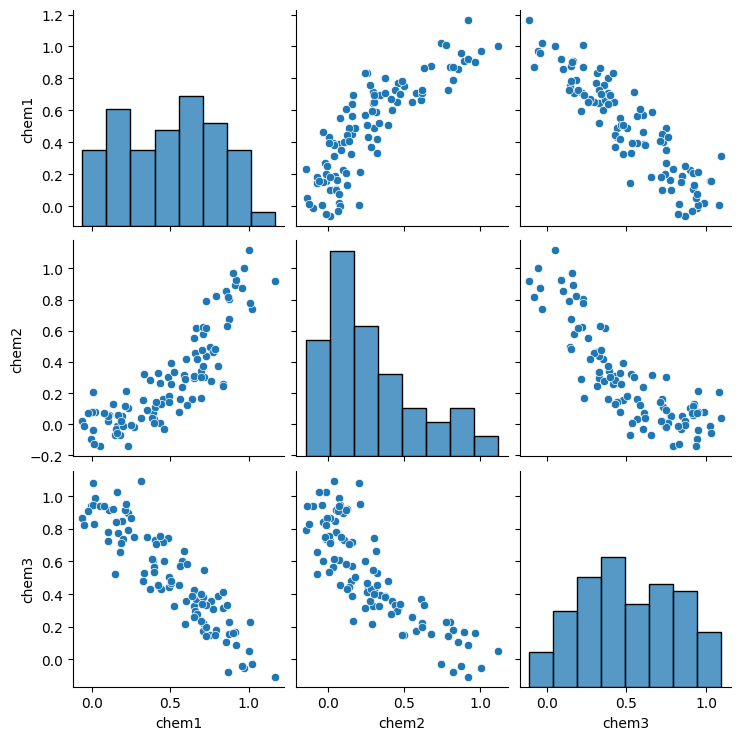

In [12]:
sns.pairplot(df_chem)

If I had to choose only three of the nine graphs, I would select the three unique scatter plots:

chem1 vs chem2

chem1 vs chem3

chem2 vs chem3

These three scatter plots show the relationships between each pair of chemicals and eliminate the duplicate mirrored plots shown in a pair plot.

The relationship between chem1 and chem3 appears strongly negative, so I would fit a linear regression line to clearly show the negative trend. Since chem3 is approximately a reverse of the base data, this relationship appears fairly linear.

The relationship between chem1 and chem2 may appear curved because chem2 is based on a squared transformation of the base data. For this plot, I would consider fitting a curved (polynomial) line or LOWESS smoothing line instead of a straight line.

The relationship between chem2 and chem3 may also show a nonlinear pattern, so I would again consider a curve rather than a straight regression line.

To improve clarity and informativeness, I would:

Remove duplicate panels (show only one triangle of the pair plot)

Add trend lines to show relationships clearly

Reduce point size and increase transparency (alpha)

Add correlation coefficients (R values) directly on the plots

Improve axis labels with units if available

If I had to choose just one graph, I would choose chem1 vs chem3 because it appears to show the strongest and clearest relationship.

If I had to choose six graphs, I would include:

The three unique scatter plots

The three histograms on the diagonal

This would show both relationships between variables and their distributions.

# 3. Homework - Reproducing Pair Plot Graphs

I'm going to show you some Pair Plot (Scatter and Histogram) graphs.  I'd like you to generate some data that will generate those graphs.

Example: this cloud involves a match between two normal distributions.

<Axes: xlabel='data1', ylabel='data2'>

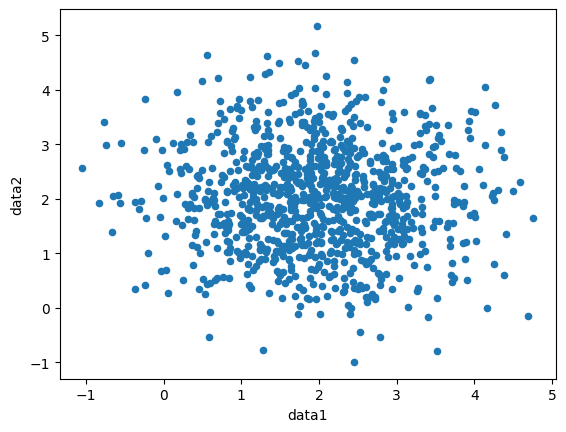

In [13]:
num_points = 1000
np.random.seed(0)
data1 = np.random.normal(size = num_points) + 2
data2 = np.random.normal(size = num_points) + 2
df_twonorm = pd.DataFrame({"data1":data1,"data2":data2})
df_twonorm.plot.scatter(x = "data1", y = "data2")

Problem: Can you design data that will generate the following scatter plot?  You may need to join multiple series to make one big series for the y-axis data.  That will allow you to create the two clouds. Use Google or ChatGPT to find the function that does that.  It is okay if the precise numbers are not re-created; just the general shape: two vertically separated clouds of points.

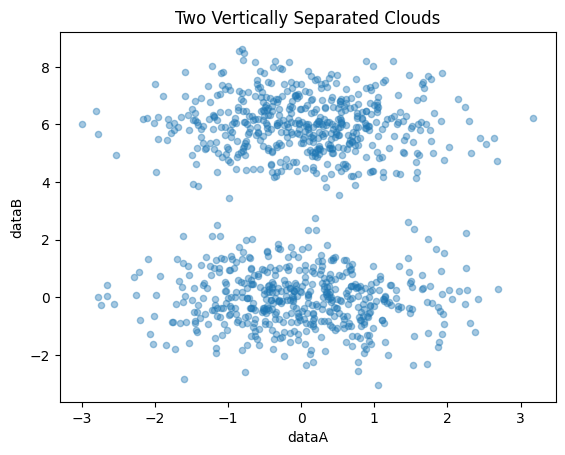

Correlation:
          dataA     dataB
dataA  1.000000  0.012893
dataB  0.012893  1.000000


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
n = 500

# Cloud 1
x1 = np.random.normal(loc=0, scale=1.0, size=n)
y1 = np.random.normal(loc=0, scale=1.0, size=n)

# Cloud 2 (shifted upward)
x2 = np.random.normal(loc=0, scale=1.0, size=n)
y2 = np.random.normal(loc=6, scale=1.0, size=n)

dataA = np.concatenate([x1, x2])
dataB = np.concatenate([y1, y2])

df_twoclouds = pd.DataFrame({"dataA": dataA, "dataB": dataB})

df_twoclouds.plot.scatter(x="dataA", y="dataB", alpha=0.4)
plt.title("Two Vertically Separated Clouds")
plt.show()

print("Correlation:")
print(df_twoclouds.corr())


Challenge problem!  Hint: you will need two series, and three segments of the first series will connect with the three segments of the second series.

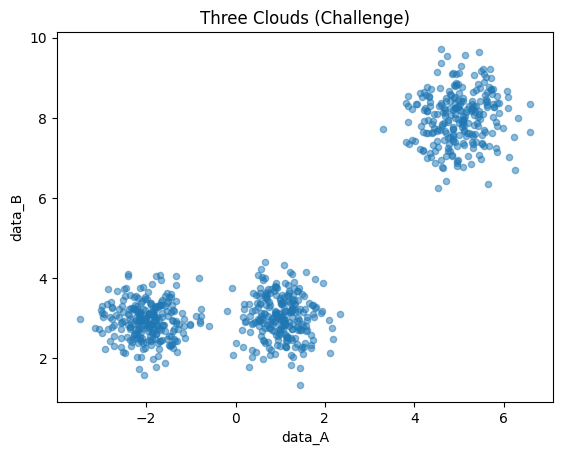

Correlation:
          data_A    data_B
data_A  1.000000  0.874288
data_B  0.874288  1.000000


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(10)
n = 250  # per segment

# data_A has 3 segments
A1 = np.random.normal(loc=-2, scale=0.5, size=n)
A2 = np.random.normal(loc= 1, scale=0.5, size=n)
A3 = np.random.normal(loc= 5, scale=0.6, size=n)

# data_B has 3 segments
B1 = np.random.normal(loc= 3, scale=0.5, size=n)
B2 = np.random.normal(loc= 3, scale=0.5, size=n)
B3 = np.random.normal(loc= 8, scale=0.7, size=n)

data_A = np.concatenate([A1, A2, A3])
data_B = np.concatenate([B1, B2, B3])

df_three = pd.DataFrame({"data_A": data_A, "data_B": data_B})

df_three.plot.scatter(x="data_A", y="data_B", alpha=0.5)
plt.title("Three Clouds (Challenge)")
plt.show()

print("Correlation:")
print(df_three.corr())


Would you expect to see a correlation for this challenge problem?  (Hint: does knowing the value of data_A tell you anything about the value of data_B - in particular, whether it is large or small?)  If you managed to reproduce the graph using data, test it yourself using the corr() function.

I used two series (data_A and data_B), and each series was created from three segments using np.concatenate(), which matches the hint. I would expect a positive correlation here because as data_A moves from low to high (left to right), data_B also tends to be higher overall (especially due to the third cloud being high in both x and y). I confirmed by checking corr().

Here is a histogram.  Can you provide data that will approximately re-create this histogram?

It is okay if the precise numbers are not re-created; just the general shape: tailing off on either side, but tailing off to a nonzero number.  (In this case, about 300).

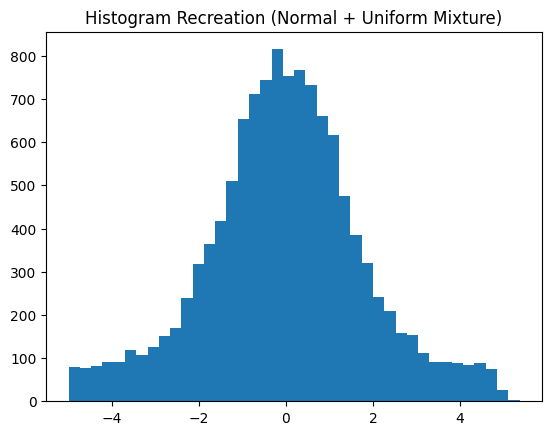

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)
n = 12000

# Main hump
main = np.random.normal(loc=0, scale=1.3, size=int(n * 0.75))

# Background noise creates nonzero tails
background = np.random.uniform(low=-5, high=5, size=int(n * 0.25))

data = np.concatenate([main, background])

plt.hist(data, bins=40)
plt.title("Histogram Recreation (Normal + Uniform Mixture)")
plt.show()


Create a line plot that shows a sales volume of soft drinks that decreases, then increases over the course of a year, in a U-shaped curve, but with some noise.

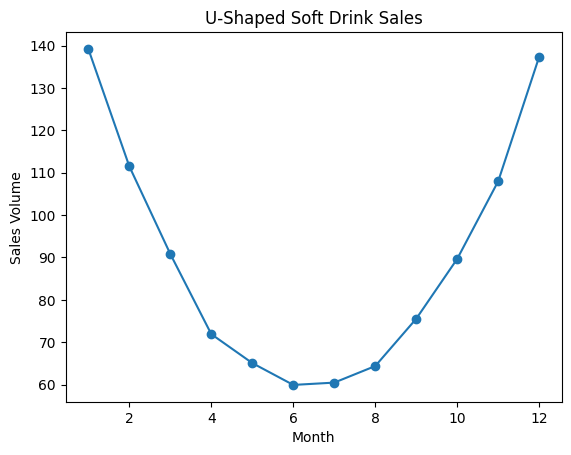

In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)
months = np.arange(1, 13)

base = (months - 6.5)**2
noise = np.random.normal(loc=0, scale=2.0, size=len(months))

sales = 60 + 2.5 * base + noise

plt.plot(months, sales, marker='o')
plt.title("U-Shaped Soft Drink Sales")
plt.xlabel("Month")
plt.ylabel("Sales Volume")
plt.show()


Create an area plot that shows the sales volume for two brands of soft drinks, one of which is increasing then decreasing, the other decreasing then increasing.

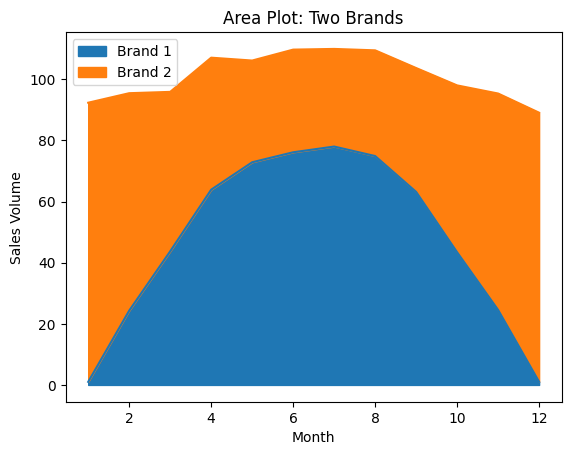

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(4)
months = np.arange(1, 13)

noise1 = np.random.normal(0, 2.0, len(months))
noise2 = np.random.normal(0, 2.0, len(months))

# Brand 1: inverted U (increase then decrease)
brand1 = 80 - 2.8 * (months - 6.5)**2 + noise1

# Brand 2: U (decrease then increase)
brand2 = 30 + 2.0 * (months - 6.5)**2 + noise2

brand1 = np.clip(brand1, 1, None)
brand2 = np.clip(brand2, 1, None)

df_area = pd.DataFrame({"Brand 1": brand1, "Brand 2": brand2}, index=months)

df_area.plot.area()
plt.title("Area Plot: Two Brands")
plt.xlabel("Month")
plt.ylabel("Sales Volume")
plt.show()


# 4. Storytelling With Data plot



Reproduce any graph of your choice in p. 71-85 of the Storytelling With Data book as best you can.  (The first half of chapter three).

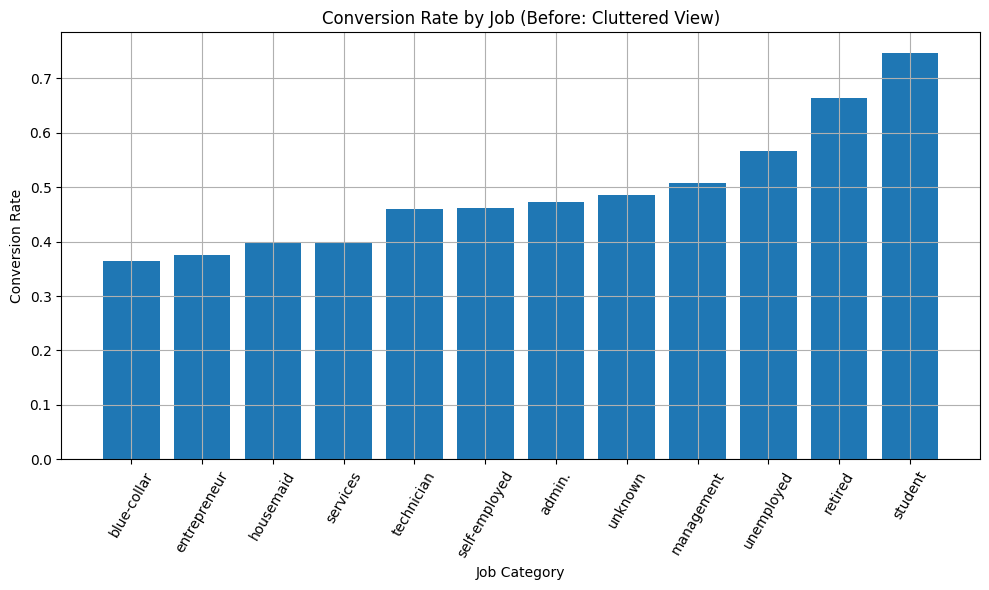

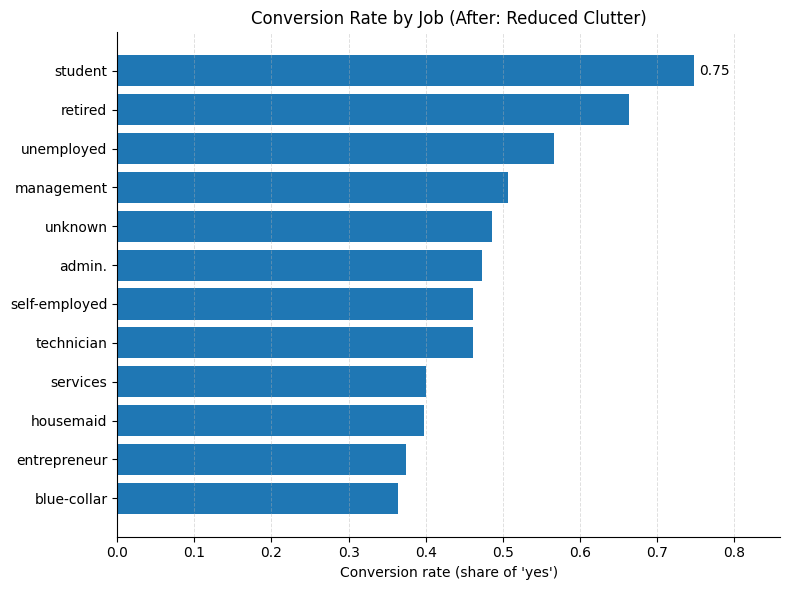

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load data safely (some versions use ; as the separator) ---
try:
    df = pd.read_csv("bank.csv")
    if df.shape[1] == 1:  # likely wrong separator
        df = pd.read_csv("bank.csv", sep=";")
except Exception:
    df = pd.read_csv("bank.csv", sep=";")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Identify target column name (some files use 'deposit', others use 'y')
target_col = "deposit" if "deposit" in df.columns else ("y" if "y" in df.columns else None)
if target_col is None:
    raise ValueError("Could not find target column. Expected 'deposit' or 'y'.")

# Compute conversion rate by job
conv_rate_by_job = (
    df[target_col].astype(str).str.lower().eq("yes")
    .groupby(df["job"])
    .mean()
    .sort_values()
)

# -------------------------
# BEFORE: cluttered version
# -------------------------
plt.figure(figsize=(10, 6))
plt.bar(conv_rate_by_job.index, conv_rate_by_job.values)
plt.title("Conversion Rate by Job (Before: Cluttered View)")
plt.xlabel("Job Category")
plt.ylabel("Conversion Rate")
plt.grid(True)                       # extra clutter
plt.xticks(rotation=60)              # harder to read
plt.tight_layout()
plt.show()

# --------------------------
# AFTER: decluttered version
# --------------------------
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Horizontal bars improve label readability (alignment + less clutter)
ax.barh(conv_rate_by_job.index, conv_rate_by_job.values)

# Clear, message-style title
ax.set_title("Conversion Rate by Job (After: Reduced Clutter)")
ax.set_xlabel("Conversion rate (share of 'yes')")
ax.set_ylabel("")  # remove unnecessary label

# Remove chart junk (spines)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Use subtle grid only on x-axis (supports reading values without clutter)
ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.4)
ax.grid(axis="y", visible=False)

# Add white space on the right for readability
ax.set_xlim(0, conv_rate_by_job.max() * 1.15)

# Optional: direct labeling of last value (simple annotation)
max_job = conv_rate_by_job.idxmax()
max_val = conv_rate_by_job.max()
ax.text(max_val * 1.01, list(conv_rate_by_job.index).index(max_job),
        f"{max_val:.2f}", va="center")

plt.tight_layout()
plt.show()

I recreated a before vs after visualization using the same data to demonstrate how removing clutter improves communication. In the first version, the chart includes extra visual noise (heavy gridlines, rotated labels, and a vertical layout). While it shows the information, it takes more effort to read and compare categories.

In the decluttered version, I applied ideas from Chapter 3:
Reduced chart junk: removed unnecessary borders (top/right spines) and avoided extra markings.

Improved alignment and readability: switched to a horizontal bar chart so the job labels align cleanly and are easier to scan.

Used white space strategically: added space on the right so bars don’t feel cramped and labels/annotations have room.

Used subtle contrast: kept only a light x-axis grid to support value reading without dominating the chart.

Direct labeling: added a simple value label for the highest category to help the viewer quickly interpret magnitude.

Overall, the after chart communicates the conversion-rate comparison more clearly and aligns with Chapter 3’s emphasis on minimizing clutter so the data stands out.